## Step 0: Get the rating curve text file for given USGS ID and clean it. Upload it to the content section as csv file with headers Stage and Discharge(cfs)

   Stage  Discharge(cfs)
0   5.33            0.02
1   5.34            0.02
2   5.35            0.02
3   5.36            0.03
4   5.37            0.03


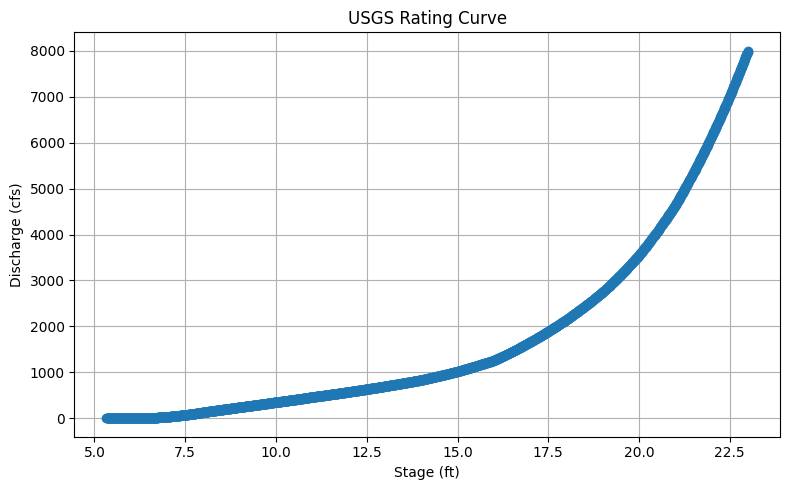

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to your cleaned file
file_path = '/content/Ratingcurve_03437495.csv'

# Read CSV file
df = pd.read_csv(file_path)

# Quick check: print first few rows
print(df.head())

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(df['Stage'], df['Discharge(cfs)'], marker='o', linestyle='-')
plt.xlabel('Stage (ft)')
plt.ylabel('Discharge (cfs)')
plt.title('USGS Rating Curve')
plt.grid(True)
plt.tight_layout()
plt.show()


# For INFRM maps, follow steps 1 to 2

## Step 1: Upload all the raster files to the content section, enter input values and execute the code

In [ ]:
import pandas as pd
import numpy as np
import os
import shutil
from scipy.interpolate import interp1d


#@title User Input
gauge_datum = 1601.2 #@param {type:"number"}
min_gauge_level = 1610.2 #@param {type:"number"}
max_gauge_level = 1646.2 #@param {type:"number"}


gauge_id ="08166200" # Assuming gauge ID from your example

# Paths
rating_curve_file = 'Ratingcurve_08166200.csv'
input_folder = '/content/'
output_folder = 'renamed_rasters/'
os.makedirs(output_folder, exist_ok=True)

# Read rating curve
df = pd.read_csv(rating_curve_file)
df = df.dropna(subset=['Stage', 'Discharge(cfs)'])

# Interpolation function (linear extrapolation)
interp_func = interp1d(df['Stage'], df['Discharge(cfs)'], fill_value="extrapolate")

# List of raster files
raster_files = [f for f in os.listdir(input_folder) if f.endswith('.tif')]

for raster_file in raster_files:
    number_part = raster_file.split('-')[1].split('.')[0]
    gauge_level = float(number_part) / 10.0
    stage = gauge_level - gauge_datum

    # Skip if stage is outside provided range
    # Skip if gauge level is outside provided range
    if gauge_level < min_gauge_level or gauge_level > max_gauge_level:
      print(f"Skipping {raster_file} (Gauge Level {gauge_level} ft out of range)")
      continue

    discharge = float(interp_func(stage))
    discharge = max(discharge, 0)  # Avoid negative discharges from extrapolation
    new_filename = f"HEC-RAS1D_{gauge_id}_{int(round(discharge))}_cfs_depth.tif"
    old_path = os.path.join(input_folder, raster_file)
    new_path = os.path.join(output_folder, new_filename)

    shutil.copy(old_path, new_path)
    print(f"Renamed {raster_file} -> {new_filename}")

print("Renaming complete. Files stored in:", output_folder)


Renamed 08166200-16187.tif -> HEC-RAS1D_08166200_52952_cfs_depth.tif
Renamed 08166200-16197.tif -> HEC-RAS1D_08166200_59112_cfs_depth.tif
Renamed 08166200-16177.tif -> HEC-RAS1D_08166200_46902_cfs_depth.tif
Renamed 08166200-16152.tif -> HEC-RAS1D_08166200_33000_cfs_depth.tif
Renamed 08166200-16247.tif -> HEC-RAS1D_08166200_95376_cfs_depth.tif
Renamed 08166200-16267.tif -> HEC-RAS1D_08166200_112495_cfs_depth.tif
Renamed 08166200-16112.tif -> HEC-RAS1D_08166200_16295_cfs_depth.tif
Renamed 08166200-16167.tif -> HEC-RAS1D_08166200_41025_cfs_depth.tif
Renamed 08166200-16312.tif -> HEC-RAS1D_08166200_157455_cfs_depth.tif
Renamed 08166200-16257.tif -> HEC-RAS1D_08166200_103755_cfs_depth.tif
Renamed 08166200-16282.tif -> HEC-RAS1D_08166200_126631_cfs_depth.tif
Renamed 08166200-16222.tif -> HEC-RAS1D_08166200_76000_cfs_depth.tif
Renamed 08166200-16327.tif -> HEC-RAS1D_08166200_173137_cfs_depth.tif
Renamed 08166200-16442.tif -> HEC-RAS1D_08166200_293370_cfs_depth.tif
Renamed 08166200-16292.tif -

## Step 2 : Download the files


In [ ]:
# Zip the renamed_rasters folder
!zip -r renamed_rasters.zip renamed_rasters

# Download the zipped file
from google.colab import files
files.download('renamed_rasters.zip')


  adding: renamed_rasters/ (stored 0%)
  adding: renamed_rasters/HEC-RAS1D_08166200_76000_cfs_depth.tif (deflated 97%)
  adding: renamed_rasters/HEC-RAS1D_08166200_314280_cfs_depth.tif (deflated 91%)
  adding: renamed_rasters/HEC-RAS1D_08166200_288142_cfs_depth.tif (deflated 92%)
  adding: renamed_rasters/HEC-RAS1D_08166200_235867_cfs_depth.tif (deflated 94%)
  adding: renamed_rasters/HEC-RAS1D_08166200_309052_cfs_depth.tif (deflated 92%)
  adding: renamed_rasters/HEC-RAS1D_08166200_178365_cfs_depth.tif (deflated 96%)
  adding: renamed_rasters/HEC-RAS1D_08166200_117000_cfs_depth.tif (deflated 97%)
  adding: renamed_rasters/HEC-RAS1D_08166200_59112_cfs_depth.tif (deflated 98%)
  adding: renamed_rasters/HEC-RAS1D_08166200_126631_cfs_depth.tif (deflated 97%)
  adding: renamed_rasters/HEC-RAS1D_08166200_23954_cfs_depth.tif (deflated 98%)
  adding: renamed_rasters/HEC-RAS1D_08166200_41025_cfs_depth.tif (deflated 98%)
  adding: renamed_rasters/HEC-RAS1D_08166200_108080_cfs_depth.tif (deflate

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# For USGS maps, follow steps 3 to 4

### Make the zip files of the folders and then upload to content section. Then give the gauge information

In [ ]:
pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 73.3 MB/s eta 0:00:00


In [ ]:
import os
import zipfile
import pandas as pd
from scipy.interpolate import interp1d
import rasterio
from rasterio.crs import CRS

# === User Parameters ===
gauge_datum = 520.0        # NAVD88 feet
gauge_id = "03437495"      # USGS gauge ID
lower_stage = 10.0         # ft above datum
upper_stage = 22.0         # ft above datum
interval = 1.0             # stage interval (ft)

rating_curve_file = "Ratingcurve_03437495.csv"
zip_file = "hopky.zip"
extract_dir = "/content/grids"
output_folder = "renamed_rasters"
os.makedirs(output_folder, exist_ok=True)

# === Step 1. Unzip ===
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# === Step 2. Rating curve ===
df = pd.read_csv(rating_curve_file).dropna(subset=['Stage', 'Discharge(cfs)'])
interp_func = interp1d(df['Stage'], df['Discharge(cfs)'], fill_value="extrapolate")

# === Step 3. Folders ===
folders = sorted([f for f in os.listdir(extract_dir) if os.path.isdir(os.path.join(extract_dir, f))])
n_stages = len(folders)

# === Step 4. Convert each ===
for idx, folder in enumerate(folders, start=1):
    folder_path = os.path.join(extract_dir, folder)

    if idx < n_stages:
        rel_stage = lower_stage + (idx - 1) * interval
    else:
        rel_stage = upper_stage

    discharge = max(float(interp_func(rel_stage)), 0)

    adf_path = os.path.join(folder_path, "w001001.adf")
    if not os.path.exists(adf_path):
        print(f"⚠️ No raster in {folder}")
        continue

    new_filename = f"HEC-RAS1D_{gauge_id}_{int(round(discharge))}_cfs_depth.tif"
    new_path = os.path.join(output_folder, new_filename)

    # --- Convert ADF → GeoTIFF ---
    with rasterio.open(adf_path) as src:
        profile = src.profile
        data = src.read()

        # Assign CRS (check metadata: often EPSG:5070 for NED, or EPSG:3857)
        profile.update(
            driver="GTiff",
            crs=CRS.from_epsg(3857),  # adjust if metadata says otherwise
            compress="LZW"            # safe compression, avoids tiling issues
        )

        with rasterio.open(new_path, "w", **profile) as dst:
            dst.write(data)

    print(f"✅ {folder} → {new_filename} (Stage {rel_stage} ft, Discharge {int(round(discharge))} cfs)")

print("🎉 All rasters converted & renamed successfully.")


✅ hopky_00 → HEC-RAS1D_03437495_352_cfs_depth.tif (Stage 10.0 ft, Discharge 352 cfs)
✅ hopky_01 → HEC-RAS1D_03437495_464_cfs_depth.tif (Stage 11.0 ft, Discharge 464 cfs)
✅ hopky_02 → HEC-RAS1D_03437495_575_cfs_depth.tif (Stage 12.0 ft, Discharge 575 cfs)
✅ hopky_03 → HEC-RAS1D_03437495_698_cfs_depth.tif (Stage 13.0 ft, Discharge 698 cfs)
✅ hopky_04 → HEC-RAS1D_03437495_834_cfs_depth.tif (Stage 14.0 ft, Discharge 834 cfs)
✅ hopky_05 → HEC-RAS1D_03437495_1020_cfs_depth.tif (Stage 15.0 ft, Discharge 1020 cfs)
✅ hopky_06 → HEC-RAS1D_03437495_1260_cfs_depth.tif (Stage 16.0 ft, Discharge 1260 cfs)
✅ hopky_07 → HEC-RAS1D_03437495_1660_cfs_depth.tif (Stage 17.0 ft, Discharge 1660 cfs)
✅ hopky_08 → HEC-RAS1D_03437495_2150_cfs_depth.tif (Stage 18.0 ft, Discharge 2150 cfs)
✅ hopky_09 → HEC-RAS1D_03437495_2750_cfs_depth.tif (Stage 19.0 ft, Discharge 2750 cfs)
✅ hopky_10 → HEC-RAS1D_03437495_3550_cfs_depth.tif (Stage 20.0 ft, Discharge 3550 cfs)
✅ hopky_11 → HEC-RAS1D_03437495_4640_cfs_depth.tif (S

### Step 4: Download renamed rasters

In [ ]:
# Zip the renamed_rasters folder
!zip -r renamed_rasters.zip renamed_rasters

# Download the zipped file
from google.colab import files
files.download('renamed_rasters.zip')

updating: renamed_rasters/ (stored 0%)
updating: renamed_rasters/HEC-RAS1D_03437495_6140_cfs_depth.tif (deflated 20%)
updating: renamed_rasters/HEC-RAS1D_03437495_1260_cfs_depth.tif (deflated 66%)
updating: renamed_rasters/HEC-RAS1D_03437495_2150_cfs_depth.tif (deflated 50%)
updating: renamed_rasters/HEC-RAS1D_03437495_575_cfs_depth.tif (deflated 77%)
updating: renamed_rasters/HEC-RAS1D_03437495_464_cfs_depth.tif (deflated 77%)
updating: renamed_rasters/HEC-RAS1D_03437495_1020_cfs_depth.tif (deflated 70%)
updating: renamed_rasters/HEC-RAS1D_03437495_2750_cfs_depth.tif (deflated 38%)
updating: renamed_rasters/HEC-RAS1D_03437495_698_cfs_depth.tif (deflated 76%)
updating: renamed_rasters/HEC-RAS1D_03437495_834_cfs_depth.tif (deflated 72%)
updating: renamed_rasters/HEC-RAS1D_03437495_3550_cfs_depth.tif (deflated 28%)
updating: renamed_rasters/HEC-RAS1D_03437495_4640_cfs_depth.tif (deflated 23%)
updating: renamed_rasters/HEC-RAS1D_03437495_352_cfs_depth.tif (deflated 78%)
updating: renamed_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>